
Summary of values read:
  Q1: 11.118870, 13.075583, 17.065890, 17.086294, 16.822757, 18.236147, 20.143394, 21.596213, 23.198469, 22.790544, 23.080335, 22.699911, 24.387824, 24.985772, 24.597829, 23.895515, 25.061485, 24.704124, 29.988619, 26.405519, 27.200698, 28.289530, 27.339404, 24.338090, 27.616515   (missing 0)
  Q2: 17.678274, 17.165212, 20.322405, 20.247905, 22.530870, 23.338415, 23.012322, 23.239031, 24.564949, 24.153533, 25.948612, 27.376524, 23.928853, 32.677237, 30.044529, 25.576580, 27.862576, 26.074288, 27.801370, 29.066899, 27.236752, 24.794756, 25.699899, 30.362405, 28.340712   (missing 0)
  Q3: 16.369425, 18.011675, 21.055450, 20.550051, 22.963235, 22.602030, 21.224987, 23.349099, 26.863515, 27.962817, 27.857451, 25.574797, 23.291032, 23.866870, 23.950241, 22.588751, 27.349212, 28.898743, 27.564150, 23.202761, 25.243401, 24.203022, 24.368782, 25.860350, 24.771458   (missing 0)
  Q4: 16.194009, 22.714954, 20.968054, 21.696392, 23.567492, 21.006013, 25.009747, 23.696347,

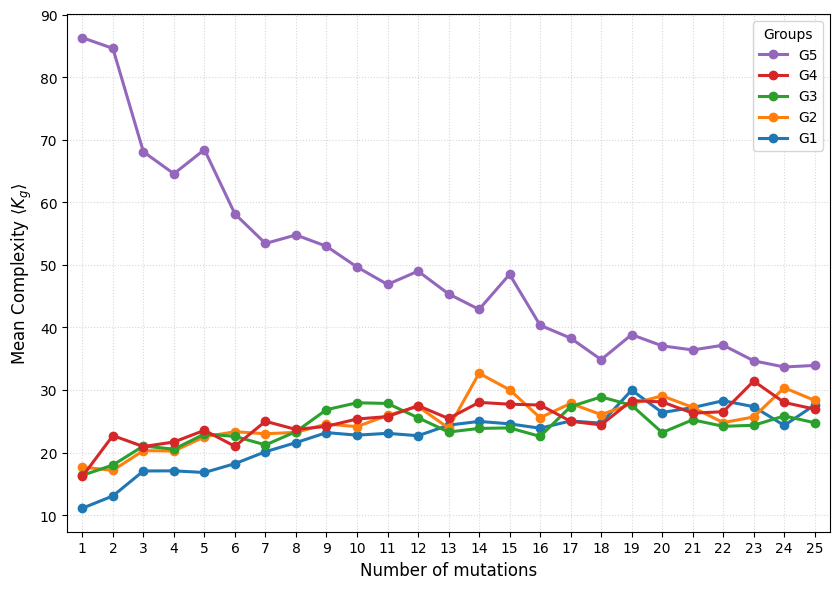

In [8]:
# Notebook-friendly plotting code (local)
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ---------- configure ----------
base_dir = Path(
    "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
    "mut_project_updates/figures/tooth model/plot_d/plot_d_files"
)
output_dir = base_dir  # change if you want to save elsewhere
Qs = ["Q1", "Q2", "Q3", "Q4", "Q5"]         # maps to G1..G5 in legend
muts = [f"mut{i}" for i in range(1, 26)]    # mut1..mut25
x_positions = np.arange(len(muts))
x_tick_labels = [str(i) for i in range(1, 26)]
marker = "o"
linewidth = 2.2
marker_size = 6
out_png = output_dir / "meanOPC_plot_mut1-25.png"
# --------------------------------

def read_numeric_file(path: Path):
    """Return the mean of numeric tokens in the file, or None if missing/unreadable."""
    try:
        text = path.read_text().strip()
        if not text:
            return None
        tokens = text.replace(",", " ").split()
        nums = []
        for t in tokens:
            try:
                nums.append(float(t))
            except ValueError:
                pass
        if not nums:
            return None
        return float(np.mean(nums))
    except FileNotFoundError:
        return None
    except Exception as e:
        print(f"Warning: failed to read {path}: {e}")
        return None

# gather data
all_values = []
per_q_missing = {}
missing_count = 0

for q in Qs:
    vals = []
    missing_for_q = 0
    for m in muts:
        path = base_dir / q / m / f"{q}_{m}_meanOPC.txt"
        val = read_numeric_file(path)
        if val is None:
            vals.append(np.nan)
            missing_for_q += 1
            missing_count += 1
        else:
            vals.append(val)
    per_q_missing[q] = missing_for_q
    all_values.append(vals)

all_values = np.array(all_values)  # shape (len(Qs), len(muts))

# print summary
print("\nSummary of values read:")
for i, q in enumerate(Qs):
    row = all_values[i]
    vals_str = ", ".join(["NaN" if np.isnan(x) else f"{x:.6f}" for x in row])
    print(f"  {q}: {vals_str}   (missing {per_q_missing[q]})")
print(f"\nTotal missing files: {missing_count}")

# plotting
plt.figure(figsize=(8.5, 6))
for i, q in enumerate(Qs):
    label = f"G{i+1}"
    plt.plot(x_positions, all_values[i],
             marker="o",
             linewidth=linewidth,
             markersize=marker_size,
             label=label)

# cosmetics
plt.xlabel("Number of mutations", fontsize=12)
plt.ylabel(r"Mean Complexity $\langle K_g \rangle$", fontsize=12)
#plt.title("Mean OPC by mutation count (mut1–mut25)", fontsize=13)
plt.xticks(x_positions, x_tick_labels)
plt.grid(True, linestyle=":", alpha=0.5)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], title="Groups",loc="upper right")
plt.xlim(x_positions[0] - 0.5, x_positions[-1] + 0.5)
plt.tight_layout()

# save & show
plt.savefig(out_png, dpi=150)
print(f"\nSaved plot to {out_png}")
plt.show()